Importando o dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

# Descompactar o arquivo ZIP
zip_file = 'srag_data.zip'  # Altere para o nome do seu arquivo ZIP

if os.path.exists(zip_file):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall()
    print(f"✅ Arquivo {zip_file} descompactado com sucesso!")
    print(f"Arquivos extraídos: {zip_ref.namelist()}")
else:
    print(f"⚠️ Arquivo {zip_file} não encontrado no diretório atual")


df = pd.read_csv('srag_data.csv', sep = ';') #vamos ver a descrição de nossa base de dados
df.columns


⚠️ Arquivo srag_data.zip não encontrado no diretório atual


/tmp/ipython-input-2610076749.py:20: DtypeWarning: Columns (14,92,94,185,186,188) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('srag_data.csv', sep = ';') #vamos ver a descrição de nossa base de dados


Index(['NU_NOTIFIC', 'DT_NOTIFIC', 'SEM_NOT', 'DT_SIN_PRI', 'SEM_PRI',
       'SG_UF_NOT', 'ID_REGIONA', 'CO_REGIONA', 'ID_MUNICIP', 'CO_MUN_NOT',
       ...
       'VG_OMS', 'VG_OMSOUT', 'VG_LIN', 'VG_MET', 'VG_METOUT', 'VG_DTRES',
       'VG_ENC', 'VG_REINF', 'VG_CODEST', 'REINF'],
      dtype='object', length=194)

In [ ]:
SEED = 42
import random
# Python random
random.seed(SEED)

# NumPy
np.random.seed(SEED)

# Garantir reprodutibilidade em operações que usam threads/OpenMP
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

In [ ]:
def clean_sivep_data(df):
    """
    Remove variáveis irrelevantes do dataset SIVEP-Gripe para modelo de classificação
    e prepara o target (evolução do caso).

    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame com os dados brutos do SIVEP-Gripe

    Returns:
    --------
    df_clean : pandas.DataFrame
        DataFrame limpo e pronto para modelagem
    """

    print("="*70)
    print("LIMPEZA DE DADOS SIVEP-GRIPE")
    print("="*70)

    # 1. FILTRAR APENAS CASOS RELEVANTES PARA O TARGET
    print(f"\n[1/4] Filtrando casos relevantes...")
    print(f"   Registros originais: {len(df)}")

    # Remover casos com evolução ignorada (9) e óbito por outras causas (3)
    df = df[df['EVOLUCAO'].isin([1, 2])].copy()
    print(f"   Após filtrar EVOLUCAO: {len(df)} registros")

    # 2. CRIAR TARGET BINÁRIO
    print(f"\n[2/4] Criando target binário...")
    df['target'] = df['EVOLUCAO'].apply(lambda x: 1 if x == 2 else 0)
    print(f"   Distribuição do target:")
    print(f"   - Classe 0 (Cura): {(df['target']==0).sum()} ({(df['target']==0).mean():.1%})")
    print(f"   - Classe 1 (Óbito): {(df['target']==1).sum()} ({(df['target']==1).mean():.1%})")

    # 3. DEFINIR TODAS AS COLUNAS A REMOVER
    print(f"\n[3/4] Definindo colunas para remoção...")

    # Campos administrativos/internos
    admin_cols = [
        'NU_NOTIFIC', 'SEM_NOT', 'SEM_PRI', 'DT_DIGITA',
        'ID_MUNICIP', 'CO_MUN_NOT', 'ID_REGIONA', 'CO_REGIONA',
        'ID_UNIDADE', 'CO_UNI_NOT', 'ID_RG_RESI', 'CO_RG_RESI',
        'ID_MN_RESI', 'CO_MUN_RES', 'ID_PAIS', 'CO_PAIS',
        'ID_RG_INTE', 'CO_RG_INTE', 'ID_MN_INTE', 'CO_MU_INTE',
        'ID_UN_INTE', 'CO_UN_INTE', 'CO_LAB_AN', 'CO_LAB_PCR'
    ]

    # Informações de identificação pessoal
    pii_cols = [
        'NU_CPF', 'NU_CNS', 'NM_PACIENT', 'NM_MAE_PAC',
        'NU_CEP', 'NM_BAIRRO', 'NM_LOGRADO', 'NU_NUMERO',
        'NM_COMPLEM', 'NU_DDD_TEL', 'NU_TELEFON'
    ]

    # Variáveis redundantes
    redundant_cols = [
        'TEM_CPF', 'ESTRANG', 'TP_IDADE', 'DT_NASC'
    ]

    # Variáveis com alta cardinalidade irrelevante
    high_card_cols = [
        'PAC_COCBO', 'PAC_DSCBO', 'CS_ETINIA', 'TP_POV_CT', 'POV_CT'
    ]

    # Campos de descrição livre/texto
    text_cols = [
        'OUTRO_DES', 'MORB_DESC', 'OUT_ANIM', 'RAIOX_OUT',
        'TOMO_OUT', 'OUT_AMOST', 'FLUASU_OUT', 'FLUBLI_OUT',
        'DS_AN_OUT', 'DS_PCR_OUT', 'OBSERVA', 'SOR_OUT',
        'OUT_SOR', 'CLASSI_OUT', 'OUT_ANTIV', 'OUT_TRAT',
        'VG_OMSOUT', 'VG_METOUT'
    ]

    # Informações do profissional
    prof_cols = [
        'NOME_PROF', 'REG_PROF', 'VG_PROF', 'VG_EST', 'VG_CODDEST'
    ]

    # Variáveis de resultado (target leakage)
    target_leakage_cols = [
        'EVOLUCAO', 'CLASSI_FIN', 'CRITERIO', 'DT_ENCERRA',
        'DT_EVOLUCA', 'NU_DO'
    ]

    # NOVAS CATEGORIAS DE REMOÇÃO:

    # 1. TODAS as datas individuais (exceto DT_SIN_PRI e DT_INTERNA que usaremos)
    date_cols = [
        'DT_NOTIFIC', 'DT_COLETA', 'DT_RES_AN', 'DT_PCR', 'DT_RAIOX',
        'DT_TOMO', 'DT_CO_SOR', 'DT_RES', 'DT_UT_DOSE', 'DT_VAC_MAE',
        'DT_DOSEUNI', 'DT_1_DOSE', 'DT_2_DOSE', 'DT_ANTIVIR', 'DT_TRT_COV',
        'DT_SAIDUTI'
    ]

    # 2. Doses individuais de vacina COVID (usaremos para feature engineering)
    vaccine_date_cols = [
        'DOSE_1_COV', 'DOSE_2_COV', 'DOSE_REF', 'DOSE_2REF',
        'DOSE_ADIC', 'DOS_RE_BI'
    ]

    # 3. Fabricantes e lotes de vacina
    vaccine_detail_cols = [
        'FAB_COV1', 'FAB_COV2', 'FAB_COVRF', 'FAB_COVRF2',
        'FAB_ADIC', 'FAB_RE_BI',
        'LOTE_1_COV', 'LOTE_2_COV', 'LOTE_REF', 'LOTE_REF2',
        'LOTE_ADIC', 'LOT_RE_BI', 'FNT_IN_COV'
    ]

    # 4. Localização geográfica detalhada
    location_cols = [
        'SG_UF_NOT', 'SG_UF', 'SG_UF_INTE'
    ]

    # 5. Vírus específicos raros - Antigênico
    rare_virus_an_cols = [
        'AN_PARA1', 'AN_PARA2', 'AN_PARA3', 'AN_ADENO', 'AN_OUTRO'
    ]

    # 6. Vírus específicos raros - PCR
    rare_virus_pcr_cols = [
        'PCR_PARA1', 'PCR_PARA2', 'PCR_PARA3', 'PCR_PARA4',
        'PCR_ADENO', 'PCR_METAP', 'PCR_BOCA', 'PCR_RINO', 'PCR_OUTRO'
    ]

    # 7. Subtipos e linhagens muito específicas
    subtypes_cols = [
        'PCR_FLUASU', 'PCR_FLUBLI'
    ]

    # 8. Detalhes de exames
    exam_detail_cols = [
        'REQUI_GAL', 'TP_TES_AN', 'LAB_AN', 'LAB_PCR'
    ]

    # 9. Tipo de amostra
    sample_type_cols = [
        'TP_AMOSTRA'
    ]

    # 10. Sorologia detalhada
    serology_cols = [
        'TP_AM_SOR', 'TP_SOR', 'RES_IGG', 'RES_IGM', 'RES_IGA'
    ]

    # 11. Vigilância genômica COMPLETA
    genomic_cols = [
        'VG_OMS', 'VG_LIN', 'VG_MET', 'VG_LAB', 'VG_CODLAB',
        'VG_DTRES', 'VG_ENC', 'VG_REINF'
    ]

    # 12. Epidemiologia secundária
    epi_secondary_cols = [
        'SURTO_SG', 'CO-DETEC'
    ]

    # 13. Contato com animais
    animal_cols = [
        'AVE_SUINO'
    ]

    # 14. Tipo de antiviral específico
    antiviral_type_cols = [
        'TP_ANTIVIR', 'TIPO_TRAT'
    ]

    # 15. Vacinação gripe - crianças < 8 anos
    vaccine_child_cols = [
        'MAE_VAC', 'DT_VAC_MAE', 'M_AMAMENTA', 'DT_DOSEUNI',
        'DT_1_DOSE', 'DT_2_DOSE'
    ]

    # Consolidar TODAS as colunas a dropar
    cols_to_drop = (
        admin_cols + pii_cols + redundant_cols + high_card_cols +
        text_cols + prof_cols + target_leakage_cols + date_cols +
        vaccine_date_cols + vaccine_detail_cols + location_cols +
        rare_virus_an_cols + rare_virus_pcr_cols + subtypes_cols +
        exam_detail_cols + sample_type_cols + serology_cols +
        genomic_cols + epi_secondary_cols + animal_cols +
        antiviral_type_cols + vaccine_child_cols
    )

    # Remover apenas colunas que existem no DataFrame
    cols_to_drop_existing = [col for col in cols_to_drop if col in df.columns]

    print(f"   Total de colunas a remover: {len(cols_to_drop_existing)}")

    # Mostrar categorias
    print(f"\n   Breakdown por categoria:")
    print(f"   - Administrativas: {len([c for c in admin_cols if c in df.columns])}")
    print(f"   - PII (dados pessoais): {len([c for c in pii_cols if c in df.columns])}")
    print(f"   - Redundantes: {len([c for c in redundant_cols if c in df.columns])}")
    print(f"   - Alta cardinalidade: {len([c for c in high_card_cols if c in df.columns])}")
    print(f"   - Texto livre: {len([c for c in text_cols if c in df.columns])}")
    print(f"   - Datas: {len([c for c in date_cols if c in df.columns])}")
    print(f"   - Vacina COVID (doses/lotes/fab): {len([c for c in vaccine_date_cols + vaccine_detail_cols if c in df.columns])}")
    print(f"   - Localização: {len([c for c in location_cols if c in df.columns])}")
    print(f"   - Vírus raros: {len([c for c in rare_virus_an_cols + rare_virus_pcr_cols if c in df.columns])}")
    print(f"   - Sorologia: {len([c for c in serology_cols if c in df.columns])}")
    print(f"   - Vigilância genômica: {len([c for c in genomic_cols if c in df.columns])}")
    print(f"   - Outras: {len(cols_to_drop_existing) - len([c for c in admin_cols + pii_cols + redundant_cols + high_card_cols + text_cols + date_cols + vaccine_date_cols + vaccine_detail_cols + location_cols + rare_virus_an_cols + rare_virus_pcr_cols + serology_cols + genomic_cols if c in df.columns])}")

    # Dropar as colunas
    df_clean = df.drop(columns=cols_to_drop_existing)

    print(f"\n[4/4] Limpeza concluída!")
    print(f"   Colunas originais: {len(df.columns)}")
    print(f"   Colunas removidas: {len(cols_to_drop_existing)}")
    print(f"   Colunas restantes: {len(df_clean.columns)}")
    print(f"   Registros finais: {len(df_clean)}")

    print("\n" + "="*70)
    print("COLUNAS MANTIDAS:")
    print("="*70)
    for i, col in enumerate(sorted(df_clean.columns), 1):
        print(f"{i:3d}. {col}")

    return df_clean

df = clean_sivep_data(df)

LIMPEZA DE DADOS SIVEP-GRIPE

[1/4] Filtrando casos relevantes...
   Registros originais: 309502
   Após filtrar EVOLUCAO: 264390 registros

[2/4] Criando target binário...
   Distribuição do target:
   - Classe 0 (Cura): 244363 (92.4%)
   - Classe 1 (Óbito): 20027 (7.6%)

[3/4] Definindo colunas para remoção...
   Total de colunas a remover: 124

   Breakdown por categoria:
   - Administrativas: 18
   - PII (dados pessoais): 0
   - Redundantes: 4
   - Alta cardinalidade: 5
   - Texto livre: 17
   - Datas: 16
   - Vacina COVID (doses/lotes/fab): 17
   - Localização: 3
   - Vírus raros: 14
   - Sorologia: 5
   - Vigilância genômica: 6
   - Outras: 19

[4/4] Limpeza concluída!
   Colunas originais: 195
   Colunas removidas: 124
   Colunas restantes: 75
   Registros finais: 264390

COLUNAS MANTIDAS:
  1. AMOSTRA
  2. ANTIVIRAL
  3. AN_SARS2
  4. AN_VSR
  5. ASMA
  6. CARDIOPATI
  7. COD_IDADE
  8. CO_DETEC
  9. CO_PS_VGM
 10. CS_ESCOL_N
 11. CS_GESTANT
 12. CS_RACA
 13. CS_SEXO
 14. CS_ZO

Com uma taxa de óbito tão baixa, talvez seja necessário balancear a base de dados usando algum metodo de oversampling da classe minoritária, como o SMOTE.

In [ ]:
pd.set_option('display.max_rows', None)

# Remover colunas completamente vazias (100% de valores nulos)
print("="*70)
print("REMOVENDO COLUNAS COM 100% DE VALORES NULOS")
print("="*70)

total_rows = len(df)
colunas_dropadas = []

for col in df.columns:
    nulos = df[col].isnull().sum()

    # Se a coluna tem 100% de nulos (iguais ao total de linhas)
    if nulos == total_rows:
        df = df.drop(columns=col)
        colunas_dropadas.append(col)
        print(f"✓ Coluna dropada: {col} (100% nulo)")

if colunas_dropadas:
    print(f"\nTotal de colunas removidas: {len(colunas_dropadas)}")
    print(f"Colunas restantes: {df.shape[1]}")
else:
    print(f"\nNenhuma coluna com 100% de nulos encontrada")
    print(f"Total de colunas: {df.shape[1]}")


REMOVENDO COLUNAS COM 100% DE VALORES NULOS
✓ Coluna dropada: TABAG (100% nulo)
✓ Coluna dropada: PAIS_VGM (100% nulo)
✓ Coluna dropada: CO_PS_VGM (100% nulo)
✓ Coluna dropada: LO_PS_VGM (100% nulo)
✓ Coluna dropada: DT_VGM (100% nulo)
✓ Coluna dropada: DT_RT_VGM (100% nulo)

Total de colunas removidas: 6
Colunas restantes: 69


In [ ]:
df = df.drop(columns= 'CS_RACA')


In [ ]:
df.columns

Index(['DT_SIN_PRI', 'CS_SEXO', 'NU_IDADE_N', 'COD_IDADE', 'CS_GESTANT',
       'CS_ESCOL_N', 'CS_ZONA', 'NOSOCOMIAL', 'FEBRE', 'TOSSE', 'GARGANTA',
       'DISPNEIA', 'DESC_RESP', 'SATURACAO', 'DIARREIA', 'VOMITO', 'OUTRO_SIN',
       'FATOR_RISC', 'PUERPERA', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN',
       'HEPATICA', 'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI',
       'IMUNODEPRE', 'RENAL', 'OBESIDADE', 'OBES_IMC', 'OUT_MORBI', 'VACINA',
       'ANTIVIRAL', 'HOSPITAL', 'DT_INTERNA', 'NM_UN_INTE', 'UTI', 'DT_ENTUTI',
       'SUPORT_VEN', 'RAIOX_RES', 'AMOSTRA', 'PCR_RESUL', 'POS_PCRFLU',
       'TP_FLU_PCR', 'POS_PCROUT', 'PCR_VSR', 'HISTO_VGM', 'PCR_SARS2',
       'DOR_ABD', 'FADIGA', 'PERD_OLFT', 'PERD_PALA', 'TOMO_RES', 'RES_AN',
       'POS_AN_FLU', 'TP_FLU_AN', 'POS_AN_OUT', 'AN_SARS2', 'AN_VSR',
       'VACINA_COV', 'FAB_COV_1', 'FAB_COV_2', 'TRAT_COV', 'CO_DETEC',
       'VG_CODEST', 'REINF', 'target'],
      dtype='object')

In [ ]:
cols_to_drop_phase_2 = [
    # Vigilância Genômica (9)
    'HISTO_VGM', 'REINF', 'VG_CODEST', 'FAB_COV_1', 'FAB_COV_2', 'NM_UN_INTE', 'CS_GESTANT', 'OBES_IMC'  # ou mesclar com PUERPERA
]
 # OBES_IMC valor continuo com muitos missings, poderiamos substituir pela mediana dos casos onde OBESIDADE = 1, mas acredito que isso poderia não ser tão bom pro algoritmo.
print(cols_to_drop_phase_2)

['HISTO_VGM', 'REINF', 'VG_CODEST', 'FAB_COV_1', 'FAB_COV_2', 'NM_UN_INTE', 'CS_GESTANT', 'OBES_IMC']


In [ ]:
df = df.drop(columns = cols_to_drop_phase_2)

In [ ]:
lista_nulos_altos = []
for col in df.columns:
    pctg_nulos = (df[col].isnull().sum()/len(df))
    if pctg_nulos > 0 and col != 'DT_INTERNA':
        lista_nulos_altos.append(col)


for col in lista_nulos_altos:
    print(df[col].value_counts())
# DROPAR:
# embora OBS_IMC seja uma variável extremamente importante para determinar o risco de vida de uma pessoa acometida poor uma doença resíratória como a covid 19, 99.7% de missing inutilizam essa variável.
# FAB_COV_2, FAB_COV_1,
# vg_codest

#NÃO DROPAR:
# TO_FLU_PCR -> SE FOR 1.0 -> INFLUENZA A, SE FOR 2.0 -> INFLUENZA B. SE FOR NULO, NÃO TEVE INFLUENZA, SEPARAR VAR. EM INF_A E INF_B E SE FOR 0 NOS DOIS DA NA MSM Q NULL.
# FATOR_RISC (2 -> NÃO É FATOR DE RISCO, 1 É FATOR DE RISCO, 9 - IGNORADO, MAS SÓ TEM 1 - 108963 CASOS, o resto deve ser considerado como não tem fator de risco? como posso garantir a qualidade)
# PUERPERA: MESMO ESQUEMA, 1.0 E 9.0 MUITO BAIXOS, DEVO CONSIDERAR QUE É NEGATIVO TBM? OU É NÃO SABEMOS? PQ SE EU USAR DESBALANCEADO ASSIM VAI DAR MERDA.
# CARDIOPATI -> MUITOS NULOS ...
# HEMATOLOGI -> MUITOS NULOS E POUCOS POSITIVOS PRA DOENÇA... DEVO CONSIDERAR OU NÃO?
# SIND_DOWN -> POUCOS CASOS DE SINDROME DE DOWN, MAS NAO TEMOS COMO SABER SE EU POSSO PREENCHER ESSAS INFORMAÇÕES... MAS UMA COISA É ESTRANHA, TODAS ESSAS INFORMAÇÕES FALTANTES TEM NA CASA DE 70.000 DADOS...
# HEPATICA -> MESMA COISA
# ASMA -> MESMA COISA
# DIABETES MESMA COISA
# OUT_MORBI


CS_ESCOL_N
9.0    54459
5.0    44982
0.0    24411
1.0    22341
3.0    11612
2.0     9584
4.0     4090
Name: count, dtype: int64
CS_ZONA
1.0    225606
2.0     16264
3.0      3138
9.0      2318
Name: count, dtype: int64
NOSOCOMIAL
2.0    226629
9.0      8424
1.0      6211
Name: count, dtype: int64
FEBRE
1.0    164366
2.0     78090
9.0       936
Name: count, dtype: int64
TOSSE
1.0    215968
2.0     36709
9.0       598
Name: count, dtype: int64
GARGANTA
2.0    179671
1.0     29126
9.0      6255
Name: count, dtype: int64
DISPNEIA
1.0    177618
2.0     64827
9.0      1066
Name: count, dtype: int64
DESC_RESP
1.0    182392
2.0     58567
9.0       720
Name: count, dtype: int64
SATURACAO
1.0    141761
2.0     89813
9.0      1543
Name: count, dtype: int64
DIARREIA
2.0    191935
1.0     20826
9.0      1929
Name: count, dtype: int64
VOMITO
2.0    183083
1.0     31154
9.0      1838
Name: count, dtype: int64
OUTRO_SIN
2.0    128007
1.0     70316
9.0      2927
Name: count, dtype: int64
FATOR_RISC
1.0 

In [ ]:
sem_nulos = []
for col in df.columns:
    pctg_nulos = (df[col].isnull().sum()/len(df))
    if pctg_nulos == 0.0:
        sem_nulos.append(col)
        print(col)



DT_SIN_PRI
CS_SEXO
NU_IDADE_N
COD_IDADE
target


In [ ]:
df.columns

Index(['DT_SIN_PRI', 'CS_SEXO', 'NU_IDADE_N', 'COD_IDADE', 'CS_ESCOL_N',
       'CS_ZONA', 'NOSOCOMIAL', 'FEBRE', 'TOSSE', 'GARGANTA', 'DISPNEIA',
       'DESC_RESP', 'SATURACAO', 'DIARREIA', 'VOMITO', 'OUTRO_SIN',
       'FATOR_RISC', 'PUERPERA', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN',
       'HEPATICA', 'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI',
       'IMUNODEPRE', 'RENAL', 'OBESIDADE', 'OUT_MORBI', 'VACINA', 'ANTIVIRAL',
       'HOSPITAL', 'DT_INTERNA', 'UTI', 'DT_ENTUTI', 'SUPORT_VEN', 'RAIOX_RES',
       'AMOSTRA', 'PCR_RESUL', 'POS_PCRFLU', 'TP_FLU_PCR', 'POS_PCROUT',
       'PCR_VSR', 'PCR_SARS2', 'DOR_ABD', 'FADIGA', 'PERD_OLFT', 'PERD_PALA',
       'TOMO_RES', 'RES_AN', 'POS_AN_FLU', 'TP_FLU_AN', 'POS_AN_OUT',
       'AN_SARS2', 'AN_VSR', 'VACINA_COV', 'TRAT_COV', 'CO_DETEC', 'target'],
      dtype='object')

In [ ]:
df['CO_DETEC'].value_counts()

,count
CO_DETEC,
2.0,180899
1.0,8462
9.0,8051


In [ ]:

cols = [
    'TRAT_COV', 'VACINA_COV', 'POS_AN_OUT', 'POS_AN_FLU', 'PERD_PALA', 'PERD_OLFT',
    'FADIGA', 'DOR_ABD', 'POS_PCROUT', 'POS_PCRFLU', 'AMOSTRA', 'UTI', 'HOSPITAL',
    'ANTIVIRAL', 'VACINA', 'OUT_MORBI', 'OBESIDADE', 'RENAL', 'IMUNODEPRE',
    'PNEUMOPATI', 'NEUROLOGIC', 'DIABETES', 'ASMA', 'HEPATICA', 'SIND_DOWN',
    'HEMATOLOGI', 'CARDIOPATI', 'OUTRO_SIN', 'VOMITO',
    'DIARREIA', 'SATURACAO', 'DESC_RESP', 'DISPNEIA', 'GARGANTA', 'TOSSE',
    'FEBRE', 'NOSOCOMIAL'
]

grupo_B = [
    'PUERPERA', 'FATOR_RISC', 'SUPORT_VEN'
]

grupo_C = [

 'RAIOX_RES', 'TOMO_RES', 'RES_AN', 'PCR_RESUL', 'CS_ESCOL_N', 'CS_ZONA', 'CS_SEXO'

]
df_clean = df.copy()

for col in cols:
    df_clean[col] = df_clean[col].replace({
        1: 1,
        2: 0,
        9: np.nan
    })
df_clean[cols] = df_clean[cols].fillna(0)

for col in grupo_B:
    df_clean[col] = df_clean[col].fillna(9).astype(int)
    df_clean = pd.get_dummies(df_clean, columns=[col], prefix=col, drop_first=True)


# === GRUPO C: dummies para resultados de exames ===
df_clean = pd.get_dummies(df_clean, columns=grupo_C, prefix=grupo_C, drop_first=True)


# === CONVERTER TODAS AS DUMMIES TRUE/FALSE → 1/0 ===
bool_cols = df_clean.select_dtypes(include=['bool']).columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)


In [ ]:
for col in df_clean.columns:
    if not col.startswith('DT') and col not in (['NU_IDADE_N', 'COD_IDADE']):
        print(df_clean[col].value_counts())

NOSOCOMIAL
0.0    258179
1.0      6211
Name: count, dtype: int64
FEBRE
1.0    164366
0.0    100024
Name: count, dtype: int64
TOSSE
1.0    215968
0.0     48422
Name: count, dtype: int64
GARGANTA
0.0    235264
1.0     29126
Name: count, dtype: int64
DISPNEIA
1.0    177618
0.0     86772
Name: count, dtype: int64
DESC_RESP
1.0    182392
0.0     81998
Name: count, dtype: int64
SATURACAO
1.0    141761
0.0    122629
Name: count, dtype: int64
DIARREIA
0.0    243564
1.0     20826
Name: count, dtype: int64
VOMITO
0.0    233236
1.0     31154
Name: count, dtype: int64
OUTRO_SIN
0.0    194074
1.0     70316
Name: count, dtype: int64
CARDIOPATI
0.0    225990
1.0     38400
Name: count, dtype: int64
HEMATOLOGI
0.0    262057
1.0      2333
Name: count, dtype: int64
SIND_DOWN
0.0    262470
1.0      1920
Name: count, dtype: int64
HEPATICA
0.0    263095
1.0      1295
Name: count, dtype: int64
ASMA
0.0    245647
1.0     18743
Name: count, dtype: int64
DIABETES
0.0    240713
1.0     23677
Name: count, dtype: 

Feature Engineering

In [ ]:
COLS = ['PCR_VSR', 'PCR_SARS2', 'AN_SARS2', 'AN_VSR']

for col in COLS:
    df_clean[col] = df_clean[col].fillna(0)
    print(df_clean[col].value_counts())

PCR_VSR
0.0    222140
1.0     42250
Name: count, dtype: int64
PCR_SARS2
0.0    256073
1.0      8317
Name: count, dtype: int64
AN_SARS2
0.0    258085
1.0      6305
Name: count, dtype: int64
AN_VSR
0.0    253196
1.0     11194
Name: count, dtype: int64


In [ ]:
df_clean['TP_FLU_PCR'] = df_clean['TP_FLU_PCR'].replace({
    1: 'Influenza_A',
    2: 'Influenza_B'
})

df_clean = pd.get_dummies(df_clean, columns=['TP_FLU_PCR'], prefix='TP_FLU_PCR', dtype=int)



In [ ]:
a = ['TP_FLU_PCR_Influenza_A', 'TP_FLU_PCR_Influenza_B']

for _ in a:
    print(df_clean[_].value_counts())

TP_FLU_PCR_Influenza_A
0    241213
1     23177
Name: count, dtype: int64
TP_FLU_PCR_Influenza_B
0    263200
1      1190
Name: count, dtype: int64


In [ ]:
df_clean.columns

Index(['DT_SIN_PRI', 'NU_IDADE_N', 'COD_IDADE', 'NOSOCOMIAL', 'FEBRE', 'TOSSE',
       'GARGANTA', 'DISPNEIA', 'DESC_RESP', 'SATURACAO', 'DIARREIA', 'VOMITO',
       'OUTRO_SIN', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN', 'HEPATICA',
       'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI', 'IMUNODEPRE', 'RENAL',
       'OBESIDADE', 'OUT_MORBI', 'VACINA', 'ANTIVIRAL', 'HOSPITAL',
       'DT_INTERNA', 'UTI', 'DT_ENTUTI', 'AMOSTRA', 'POS_PCRFLU', 'POS_PCROUT',
       'PCR_VSR', 'PCR_SARS2', 'DOR_ABD', 'FADIGA', 'PERD_OLFT', 'PERD_PALA',
       'POS_AN_FLU', 'TP_FLU_AN', 'POS_AN_OUT', 'AN_SARS2', 'AN_VSR',
       'VACINA_COV', 'TRAT_COV', 'CO_DETEC', 'target', 'PUERPERA_2',
       'PUERPERA_9', 'FATOR_RISC_9', 'SUPORT_VEN_2', 'SUPORT_VEN_3',
       'SUPORT_VEN_9', 'RAIOX_RES_2.0', 'RAIOX_RES_3.0', 'RAIOX_RES_4.0',
       'RAIOX_RES_5.0', 'RAIOX_RES_6.0', 'RAIOX_RES_9.0', 'TOMO_RES_2.0',
       'TOMO_RES_3.0', 'TOMO_RES_4.0', 'TOMO_RES_5.0', 'TOMO_RES_6.0',
       'TOMO_RES_9.0', 'RES_AN_2.0', 

Feature Engineering

In [ ]:
df_clean['DT_SIN_PRI'] = pd.to_datetime(df_clean['DT_SIN_PRI'], errors='coerce')
df_clean['DT_INTERNA'] = pd.to_datetime(df_clean['DT_INTERNA'], errors='coerce')
df_clean['DT_ENTUTI'] = pd.to_datetime(df_clean['DT_ENTUTI'], errors='coerce')

# Manter NA e remover apenas inconsistências
df_clean = df_clean[
    (df_clean['DT_INTERNA'].isna()) |
    (df_clean['DT_SIN_PRI'] <= df_clean['DT_INTERNA'])
]

df_clean = df_clean[
    (df_clean['DT_ENTUTI'].isna()) |
    (df_clean['DT_SIN_PRI'] <= df_clean['DT_ENTUTI'])
]

# Dias até internação
df_clean['dias_entre_sintomas_e_internacao'] = \
    (df_clean['DT_INTERNA'] - df_clean['DT_SIN_PRI']).dt.days

# Dias até UTI
df_clean['dias_entre_sintomas_e_uti'] = \
    (df_clean['DT_ENTUTI'] - df_clean['DT_SIN_PRI']).dt.days


In [ ]:
df_clean['dias_entre_sintomas_e_internacao'].value_counts()

,count
dias_entre_sintomas_e_internacao,
0.0,41561
2.0,40004
1.0,39054
3.0,37893
4.0,26733
5.0,17856
7.0,12362
6.0,11961
8.0,4281


In [ ]:
df_clean['dias_entre_sintomas_e_uti'].value_counts()

,count
dias_entre_sintomas_e_uti,
2.0,9652
3.0,9391
1.0,9363
0.0,8506
4.0,7578
5.0,5594
6.0,3811
7.0,3458
8.0,1655


In [ ]:
df_clean[(df_clean['dias_entre_sintomas_e_internacao'] > 60) & (df_clean['target'] == 1)].count()/len(df_clean[df_clean['target'] == 1])

,0
DT_SIN_PRI,0.002187
NU_IDADE_N,0.002187
COD_IDADE,0.002187
NOSOCOMIAL,0.002187
FEBRE,0.002187
TOSSE,0.002187
GARGANTA,0.002187
DISPNEIA,0.002187
DESC_RESP,0.002187
SATURACAO,0.002187


In [ ]:
df_clean = df_clean[(df_clean['dias_entre_sintomas_e_internacao'] < 60) | df_clean['dias_entre_sintomas_e_uti'].isna()]
df_clean = df_clean[(df_clean['dias_entre_sintomas_e_uti'] < 60) | df_clean['dias_entre_sintomas_e_uti'].isna()]

In [ ]:
for _ in df_clean.columns:
    print(df_clean[_].value_counts())


DT_SIN_PRI
2025-06-01    2303
2025-05-20    1969
2025-05-25    1927
2025-05-01    1833
2025-05-10    1812
2025-05-26    1795
2025-06-10    1788
2025-05-23    1781
2025-05-18    1764
2025-05-15    1755
2025-06-02    1720
2025-05-19    1719
2025-06-06    1710
2025-05-17    1691
2025-05-12    1665
2025-05-24    1657
2025-05-22    1645
2025-06-20    1639
2025-05-16    1637
2025-05-28    1628
2025-06-05    1624
2025-05-30    1615
2025-05-14    1595
2025-05-05    1587
2025-05-21    1562
2025-05-27    1553
2025-06-03    1548
2025-05-13    1540
2025-06-09    1527
2025-06-04    1522
2025-06-15    1506
2025-05-31    1492
2025-06-08    1481
2025-05-08    1473
2025-06-16    1472
2025-06-07    1469
2025-06-13    1461
2025-05-03    1460
2025-05-09    1448
2025-05-02    1444
2025-05-29    1422
2025-05-11    1413
2025-06-12    1398
2025-05-04    1387
2025-07-01    1378
2025-06-14    1365
2025-05-06    1354
2025-04-20    1336
2025-05-07    1323
2025-06-18    1312
2025-06-19    1305
2025-06-11    1289
2

In [ ]:
df_clean.shape

(260704, 92)

In [ ]:
df_clean['dias_entre_sintomas_e_uti'] = df_clean['dias_entre_sintomas_e_uti'].fillna(-1)
df_clean['dias_entre_sintomas_e_internacao'] = df_clean['dias_entre_sintomas_e_internacao'].fillna(-1)

In [ ]:
df_clean.shape

(260704, 92)

In [ ]:
df_clean.head()

,DT_SIN_PRI,NU_IDADE_N,COD_IDADE,NOSOCOMIAL,FEBRE,TOSSE,GARGANTA,DISPNEIA,DESC_RESP,SATURACAO,...,CS_ESCOL_N_9.0,CS_ZONA_2.0,CS_ZONA_3.0,CS_ZONA_9.0,CS_SEXO_I,CS_SEXO_M,TP_FLU_PCR_Influenza_A,TP_FLU_PCR_Influenza_B,dias_entre_sintomas_e_internacao,dias_entre_sintomas_e_uti
0,2024-12-29,63,3063,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,1,0,0,0,0,1,0,0,-1.0,-1.0
1,2024-12-29,1,2001,0.0,0.0,1.0,0.0,1.0,1.0,1.0,...,0,0,0,0,0,0,0,0,-1.0,-1.0
2,2024-12-29,88,3088,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0,0,0,0,0,1,0,0,0.0,3.0
3,2024-12-29,3,2003,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0,1,0,0,0,0,0,0,0.0,0.0
4,2024-12-29,66,3066,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1,0,0,0,0,1,0,0,-1.0,-1.0


/tmp/ipython-input-882232697.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_clean = df_clean[df['NU_IDADE_N'] < 109.0]


<Axes: xlabel='NU_IDADE_N', ylabel='Count'>

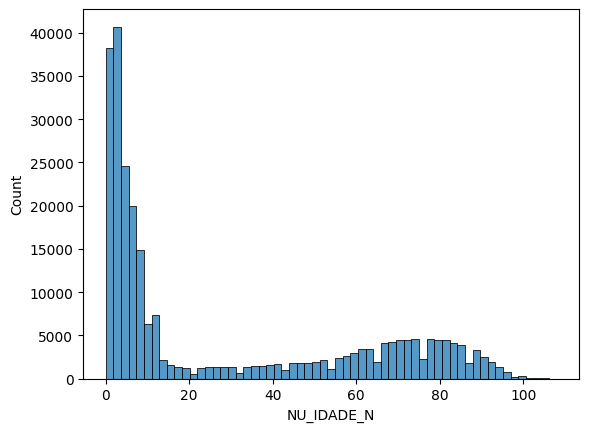

In [ ]:
df_clean = df_clean[df['NU_IDADE_N'] < 109.0]
sns.histplot(df_clean, x = 'NU_IDADE_N')

/tmp/ipython-input-4208260917.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='NU_IDADE_N', data=df_clean, palette='viridis')


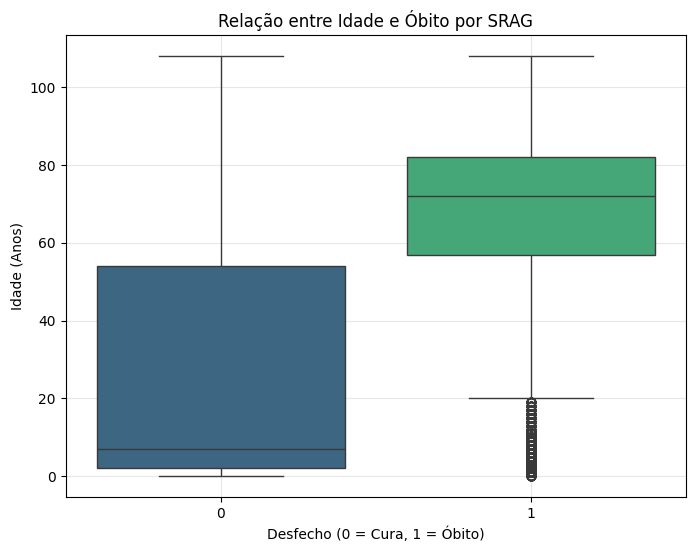

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
# Boxplot: Compara a distribuição de idade entre Cura (0) e Óbito (1)
sns.boxplot(x='target', y='NU_IDADE_N', data=df_clean, palette='viridis')

plt.title('Relação entre Idade e Óbito por SRAG')
plt.xlabel('Desfecho (0 = Cura, 1 = Óbito)')
plt.ylabel('Idade (Anos)')
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipython-input-2443226605.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(x='target', data=df_clean, palette='viridis')
/tmp/ipython-input-2443226605.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='NU_IDADE_N', data=df_clean, palette='viridis')


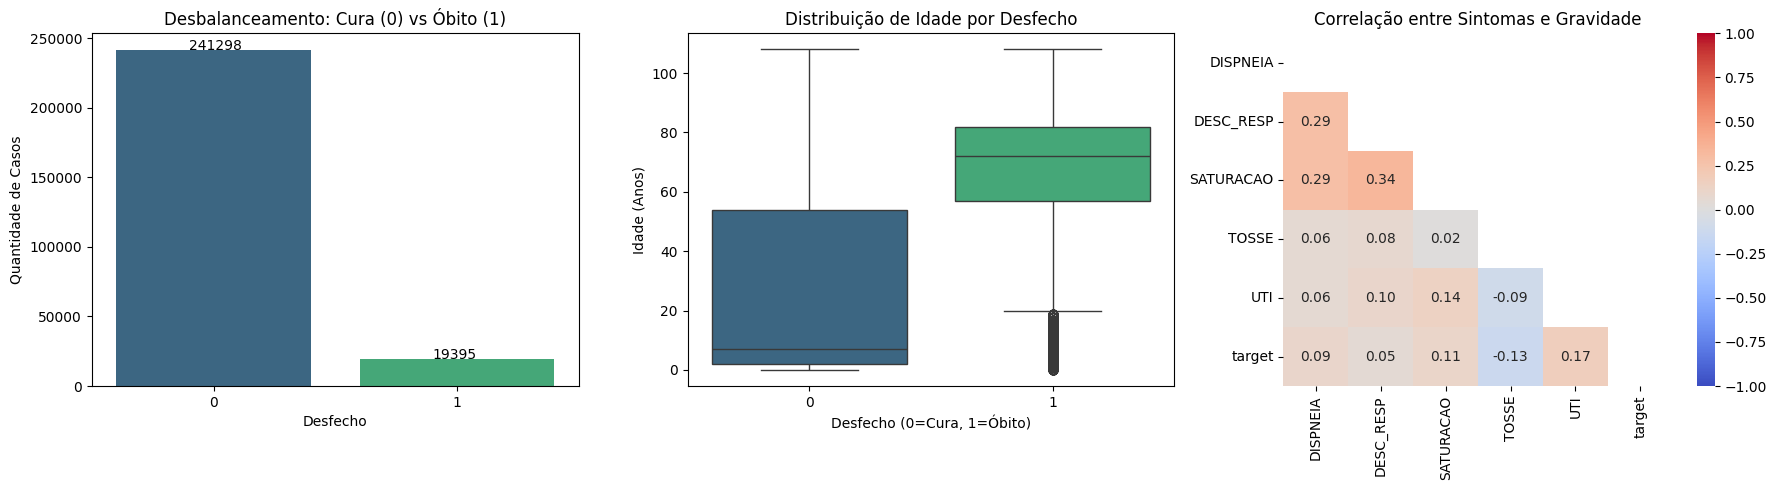

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurar tamanho dos gráficos
plt.figure(figsize=(18, 5))

# GRÁFICO 1: Desbalanceamento (Cura vs Óbito)
# Suporta o item "3.1 Distribuição da Variável Resposta"
plt.subplot(1, 3, 1)
ax1 = sns.countplot(x='target', data=df_clean, palette='viridis')
plt.title('Desbalanceamento: Cura (0) vs Óbito (1)')
plt.xlabel('Desfecho')
plt.ylabel('Quantidade de Casos')
# Adiciona os números em cima das barras
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 100))

# GRÁFICO 2: Idade vs Óbito (Boxplot)
# Suporta o item "3.2 Variáveis Numéricas" (mostra que quem morre é mais velho)
plt.subplot(1, 3, 2)
sns.boxplot(x='target', y='NU_IDADE_N', data=df_clean, palette='viridis')
plt.title('Distribuição de Idade por Desfecho')
plt.xlabel('Desfecho (0=Cura, 1=Óbito)')
plt.ylabel('Idade (Anos)')

# GRÁFICO 3: Matriz de Correlação (Sintomas)
# Suporta o item "3.3 Multicolinearidade"
plt.subplot(1, 3, 3)
# Selecionando apenas sintomas principais para não poluir
cols_corr = ['DISPNEIA', 'DESC_RESP', 'SATURACAO', 'TOSSE', 'UTI', 'target']
corr = df_clean[cols_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool)) # Esconde a parte repetida do triângulo
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlação entre Sintomas e Gravidade')

plt.tight_layout()
plt.show()

/tmp/ipython-input-601744758.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='target', data=df_clean, palette='viridis')


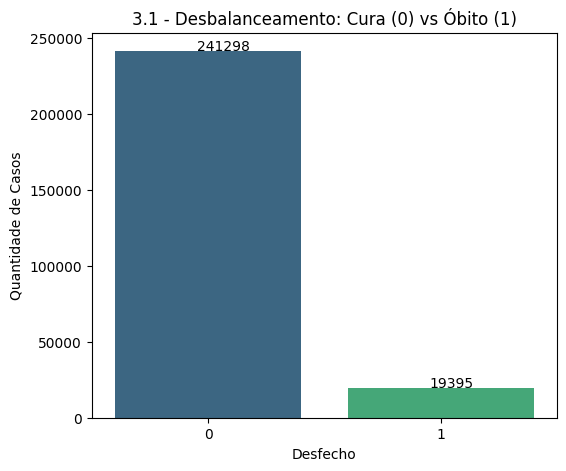

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

# Gráfico de contagem
ax = sns.countplot(x='target', data=df_clean, palette='viridis')

plt.title('3.1 - Desbalanceamento: Cura (0) vs Óbito (1)')
plt.xlabel('Desfecho')
plt.ylabel('Quantidade de Casos')

# Colocar os números em cima das barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + 0.35, p.get_height() + 500))

plt.show()

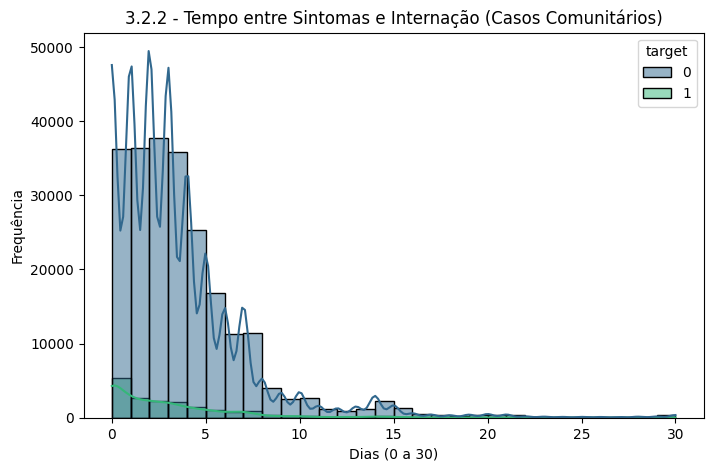

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

# FILTRO NOVO: Pegamos apenas dias >= 0 e < 30 para o gráfico ficar bonito
df_grafico = df_clean.query("dias_entre_sintomas_e_internacao >= 0 & dias_entre_sintomas_e_internacao <= 30")

sns.histplot(data=df_grafico, x='dias_entre_sintomas_e_internacao',
             hue='target', kde=True, palette='viridis', bins=30)

plt.title('3.2.2 - Tempo entre Sintomas e Internação (Casos Comunitários)')
plt.xlabel('Dias (0 a 30)')
plt.ylabel('Frequência')

plt.show()

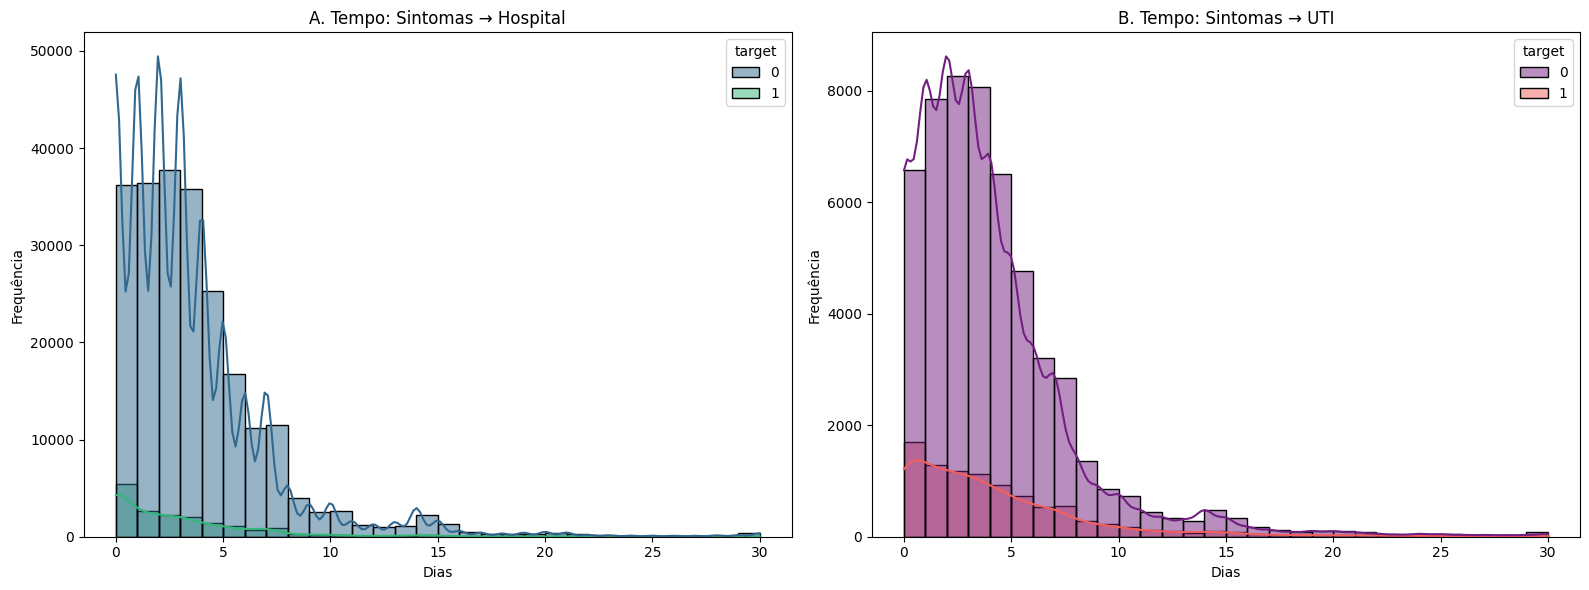

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configura o tamanho para caber os dois gráficos lado a lado
plt.figure(figsize=(16, 6))

# --- GRÁFICO 1: TEMPO ATÉ INTERNAÇÃO (Esquerda) ---
plt.subplot(1, 2, 1)
# Filtro: Apenas dias positivos e até 30 dias
df_interna = df_clean.query("dias_entre_sintomas_e_internacao >= 0 & dias_entre_sintomas_e_internacao <= 30")

sns.histplot(data=df_interna, x='dias_entre_sintomas_e_internacao',
             hue='target', kde=True, palette='viridis', bins=30)
plt.title('A. Tempo: Sintomas → Hospital')
plt.xlabel('Dias')
plt.ylabel('Frequência')

# --- GRÁFICO 2: TEMPO ATÉ UTI (Direita) ---
plt.subplot(1, 2, 2)
# Filtro: Apenas dias positivos e até 30 dias (Note que usamos a variável _uti aqui)
df_uti = df_clean.query("dias_entre_sintomas_e_uti >= 0 & dias_entre_sintomas_e_uti <= 30")

sns.histplot(data=df_uti, x='dias_entre_sintomas_e_uti',
             hue='target', kde=True, palette='magma', bins=30) # Usei 'magma' pra diferenciar a cor
plt.title('B. Tempo: Sintomas → UTI')
plt.xlabel('Dias')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

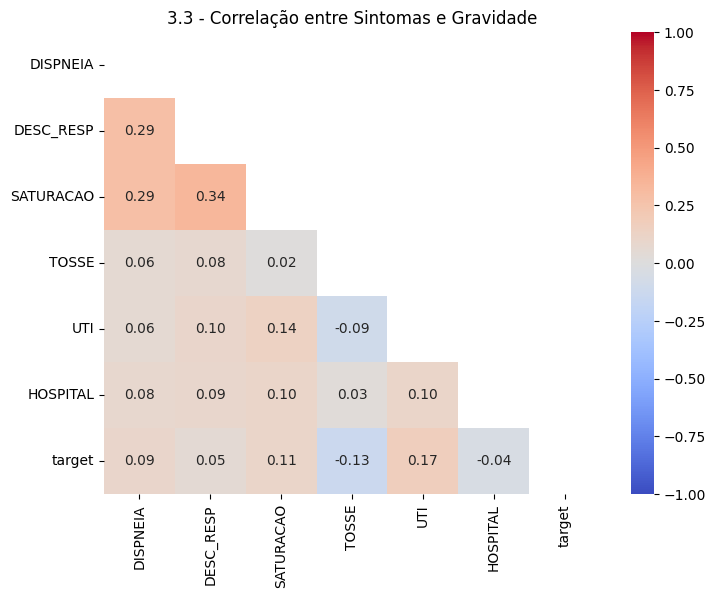

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8, 6))

# Selecionando apenas as variáveis de interesse para o gráfico ficar legível
cols_corr = ['DISPNEIA', 'DESC_RESP', 'SATURACAO', 'TOSSE', 'UTI', 'HOSPITAL', 'target']
corr = df_clean[cols_corr].corr()

# Máscara para esconder a metade repetida do gráfico
mask = np.triu(np.ones_like(corr, dtype=bool))

# Mapa de calor
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm',
            fmt=".2f", vmin=-1, vmax=1)

plt.title('3.3 - Correlação entre Sintomas e Gravidade')
plt.show()

In [ ]:
# Faixas refinadas baseadas em conhecimento epidemiológico
bins_refinado = [0, 2, 5, 18, 40, 60, 80, 200]
labels_refinado = ['0_1', '2_4', '5_17', '18_39', '40_59', '60_79', '80_plus']

df_clean['faixa_refinada'] = pd.cut(
    df_clean['NU_IDADE_N'],
    bins=bins_refinado,
    labels=labels_refinado,
    right=False
)

df_clean = pd.get_dummies(df_clean, columns=['faixa_refinada'])


In [ ]:
df_clean.columns

Index(['DT_SIN_PRI', 'NU_IDADE_N', 'COD_IDADE', 'NOSOCOMIAL', 'FEBRE', 'TOSSE',
       'GARGANTA', 'DISPNEIA', 'DESC_RESP', 'SATURACAO', 'DIARREIA', 'VOMITO',
       'OUTRO_SIN', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN', 'HEPATICA',
       'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI', 'IMUNODEPRE', 'RENAL',
       'OBESIDADE', 'OUT_MORBI', 'VACINA', 'ANTIVIRAL', 'HOSPITAL',
       'DT_INTERNA', 'UTI', 'DT_ENTUTI', 'AMOSTRA', 'POS_PCRFLU', 'POS_PCROUT',
       'PCR_VSR', 'PCR_SARS2', 'DOR_ABD', 'FADIGA', 'PERD_OLFT', 'PERD_PALA',
       'POS_AN_FLU', 'TP_FLU_AN', 'POS_AN_OUT', 'AN_SARS2', 'AN_VSR',
       'VACINA_COV', 'TRAT_COV', 'CO_DETEC', 'target', 'PUERPERA_2',
       'PUERPERA_9', 'FATOR_RISC_9', 'SUPORT_VEN_2', 'SUPORT_VEN_3',
       'SUPORT_VEN_9', 'RAIOX_RES_2.0', 'RAIOX_RES_3.0', 'RAIOX_RES_4.0',
       'RAIOX_RES_5.0', 'RAIOX_RES_6.0', 'RAIOX_RES_9.0', 'TOMO_RES_2.0',
       'TOMO_RES_3.0', 'TOMO_RES_4.0', 'TOMO_RES_5.0', 'TOMO_RES_6.0',
       'TOMO_RES_9.0', 'RES_AN_2.0', 

<Axes: xlabel='faixa_refinada_80_plus', ylabel='count'>

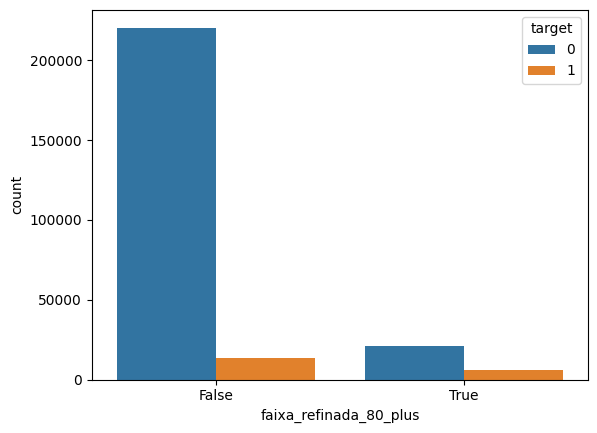

In [ ]:
sns.countplot(
    data=df_clean,
    x='faixa_refinada_80_plus',
    hue='target'
)

<Axes: xlabel='faixa_refinada_60_79', ylabel='count'>

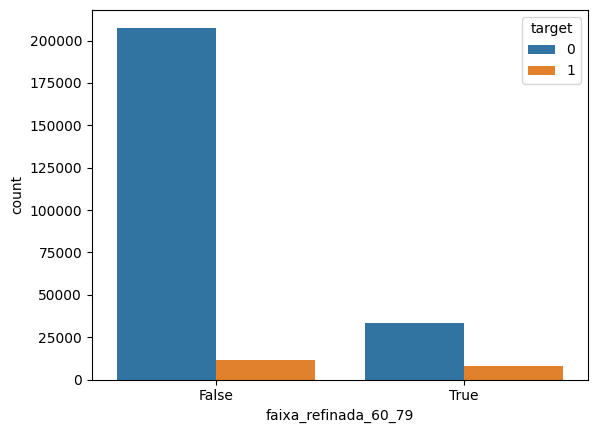

In [ ]:
sns.countplot(
    data=df_clean,
    x='faixa_refinada_60_79',
    hue='target'
)

In [ ]:
df_clean["CO_DETEC"] = df_clean["CO_DETEC"].replace({
    1: 1,
    2: 0,
    9: -1
})

df_clean["CO_DETEC"] = df_clean["CO_DETEC"].fillna(-1)


Modelo

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
y = df_clean['target'].astype(int)
X = df_clean.drop(columns = ['target', 'DT_SIN_PRI', 'DT_INTERNA', 'DT_ENTUTI', 'TP_FLU_AN', 'COD_IDADE'])
X.isnull().sum()

,0
NU_IDADE_N,0
NOSOCOMIAL,0
FEBRE,0
TOSSE,0
GARGANTA,0
DISPNEIA,0
DESC_RESP,0
SATURACAO,0
DIARREIA,0
VOMITO,0


In [ ]:
df_clean.shape

(260693, 99)

In [71]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# --- 1. PREPARAÇÃO DOS DADOS COM CONVERSÃO DE TIPO ---
# Convertendo para lista
cols_selecionadas = list(selected_features)

# TRUQUE PARA CORRIGIR O ERRO:
# Forçamos tudo ser número (float). True vira 1.0, False vira 0.0.
X_train_temp = X_train[cols_selecionadas].astype(float)
y_train_temp = y_train.astype(float).reset_index(drop=True)

# Adicionando a constante (intercepto) manualmente
X_train_sm = sm.add_constant(X_train_temp)

# Garantindo que os índices batem (para evitar erro de alinhamento)
X_train_sm.reset_index(drop=True, inplace=True)

# --- 2. CRIANDO O MODELO ESTATÍSTICO ---
logit_sm = sm.Logit(y_train_temp, X_train_sm)
result_sm = logit_sm.fit(disp=0) # disp=0 esconde o log de iterações

# --- 3. GERANDO A TABELA FINAL ---
tabela_coef = pd.DataFrame({
    'Coeficiente': result_sm.params,
    'Erro Padrão': result_sm.bse,
    'P-Valor': result_sm.pvalues,
    'Razão de Chance (OR)': np.exp(result_sm.params)
})

print("=== COPIE ESTA TABELA PARA A SEÇÃO 5.1 ===")
print(tabela_coef.round(4))

=== COPIE ESTA TABELA PARA A SEÇÃO 5.1 ===
                                  Coeficiente  Erro Padrão  P-Valor  \
const                                 -2.3184       0.2614   0.0000   
NU_IDADE_N                             0.0368       0.0007   0.0000   
TOSSE                                 -0.5420       0.0231   0.0000   
DISPNEIA                               0.3209       0.0289   0.0000   
DESC_RESP                              0.2889       0.0265   0.0000   
SATURACAO                              0.1896       0.0255   0.0000   
ASMA                                  -0.5373       0.0499   0.0000   
NEUROLOGIC                             0.4645       0.0378   0.0000   
HOSPITAL                              -1.2734       0.0517   0.0000   
UTI                                    0.3494       0.0308   0.0000   
PUERPERA_2                             0.8520       0.2496   0.0006   
PUERPERA_9                             0.6880       0.2496   0.0058   
SUPORT_VEN_2                      

/tmp/ipython-input-309359599.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subset_faixas['Coeficiente'], y=subset_faixas.index, palette=cores)


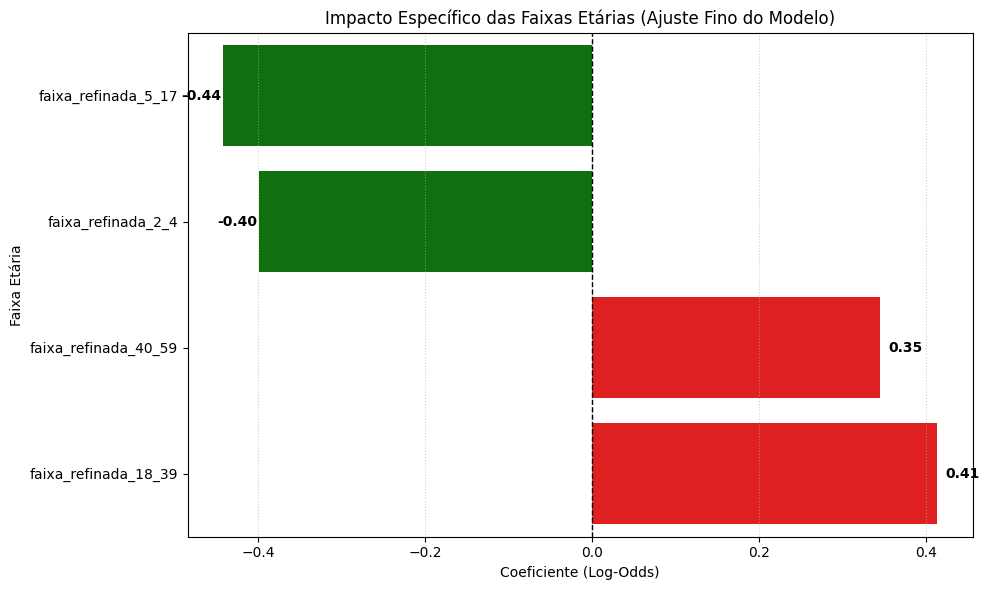

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- FILTRANDO APENAS AS FAIXAS ETÁRIAS ---
# Procura linhas na tabela de coeficientes que tenham "faixa" ou "refinada" no nome
# (Ajuste a string 'faixa' se o nome da sua coluna for diferente, ex: 'AGE_')
subset_faixas = tabela_coef[tabela_coef.index.str.contains('faixa', case=False)].sort_values(by='Coeficiente')

# --- GERANDO O GRÁFICO ---
plt.figure(figsize=(10, 6))

# Cores: Verde para Proteção (Negativo), Vermelho para Risco (Positivo)
cores = ['green' if x < 0 else 'red' for x in subset_faixas['Coeficiente']]

sns.barplot(x=subset_faixas['Coeficiente'], y=subset_faixas.index, palette=cores)

plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Impacto Específico das Faixas Etárias (Ajuste Fino do Modelo)')
plt.xlabel('Coeficiente (Log-Odds)')
plt.ylabel('Faixa Etária')
plt.grid(axis='x', linestyle=':', alpha=0.6)

# Adiciona o valor na ponta da barra
for i, v in enumerate(subset_faixas['Coeficiente']):
    offset = 0.01 if v >= 0 else -0.05
    plt.text(v + offset, i, f'{v:.2f}', va='center', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
X.count()

,0
NU_IDADE_N,260693
NOSOCOMIAL,260693
FEBRE,260693
TOSSE,260693
GARGANTA,260693
DISPNEIA,260693
DESC_RESP,260693
SATURACAO,260693
DIARREIA,260693
VOMITO,260693


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X, y, test_size=0.3, random_state=SEED, stratify=y
)

In [ ]:
df_clean.isna().sum()

,0
DT_SIN_PRI,0
NU_IDADE_N,0
COD_IDADE,0
NOSOCOMIAL,0
FEBRE,0
TOSSE,0
GARGANTA,0
DISPNEIA,0
DESC_RESP,0
SATURACAO,0


In [ ]:
model = LogisticRegression(class_weight="balanced", max_iter= 1000,penalty='l2')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.80      0.88     72389
           1       0.25      0.86      0.39      5819

    accuracy                           0.80     78208
   macro avg       0.62      0.83      0.64     78208
weighted avg       0.93      0.80      0.84     78208

[[57639 14750]
 [  791  5028]]


In [ ]:
X = X.astype(float)
X.dtypes

,0
NU_IDADE_N,float64
NOSOCOMIAL,float64
FEBRE,float64
TOSSE,float64
GARGANTA,float64
DISPNEIA,float64
DESC_RESP,float64
SATURACAO,float64
DIARREIA,float64
VOMITO,float64


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel

# 1. Pipeline para obter coeficientes
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        penalty='l1',
        class_weight='balanced',
        solver='saga',
        C=1.0,
        max_iter=5000,
        random_state=SEED
    ))
])

pipe.fit(X_train, y_train)

# 2. Seleção das features
selector = SelectFromModel(pipe.named_steps['clf'], prefit=True, threshold="mean")
selected = selector.get_support()
selected_features = X_train.columns[selected]

print("Selected features:", selected_features.tolist())

# 3. ESCALAR novamente — AGORA de forma correta
scaler_final = StandardScaler()
X_train_final = scaler_final.fit_transform(X_train[selected_features])
X_test_final  = scaler_final.transform(X_test[selected_features])

# 4. Treinar modelo final CONSISTENTE
clf_final = LogisticRegression(
    class_weight='balanced',
    solver='lbfgs',
    max_iter=2000
)

clf_final.fit(X_train_final, y_train)

# 5. Avaliar
from sklearn.metrics import classification_report
y_pred = clf_final.predict(X_test_final)
print(classification_report(y_test, y_pred))


Selected features: ['NU_IDADE_N', 'TOSSE', 'DISPNEIA', 'DESC_RESP', 'SATURACAO', 'ASMA', 'NEUROLOGIC', 'HOSPITAL', 'UTI', 'PUERPERA_2', 'PUERPERA_9', 'SUPORT_VEN_2', 'SUPORT_VEN_3', 'SUPORT_VEN_9', 'RES_AN_2.0', 'RES_AN_5.0', 'dias_entre_sintomas_e_internacao', 'dias_entre_sintomas_e_uti', 'faixa_refinada_2_4', 'faixa_refinada_5_17', 'faixa_refinada_18_39', 'faixa_refinada_40_59']
              precision    recall  f1-score   support

           0       0.99      0.79      0.87     72389
           1       0.24      0.86      0.38      5819

    accuracy                           0.79     78208
   macro avg       0.62      0.82      0.63     78208
weighted avg       0.93      0.79      0.84     78208



In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
probs = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, probs)
print("AUC:", auc)

AUC: 0.9065933661181647


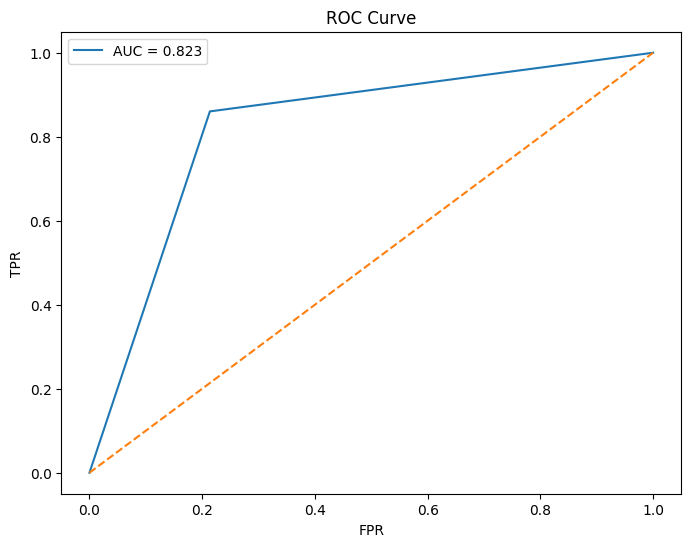

In [ ]:
from sklearn.metrics import roc_curve, auc

probs = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], '--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [ ]:
probs = model.predict_proba(X_test)[:, 1]
len(np.unique(probs))

78092

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
# Calculate the AUC - ROC score
roc_auc = roc_auc_score(y_test, probs)

# Calculate other metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the metrics
print(f"AUC - ROC Score: {roc_auc:.2f}")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

AUC - ROC Score: 0.91
Accuracy: 0.79
Precision: 0.24
Recall: 0.86
F1 Score: 0.38


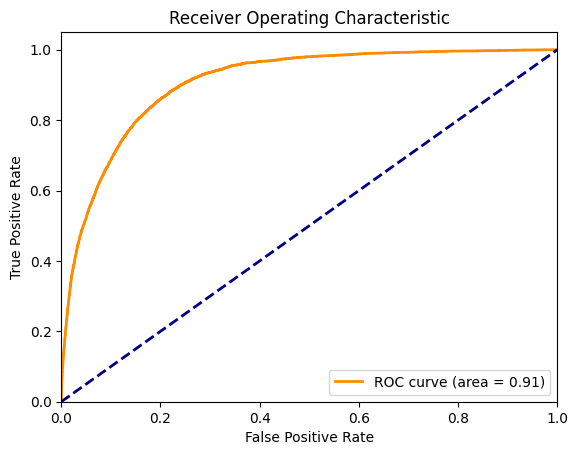

In [ ]:
# Plotting the ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [ ]:
import statsmodels.api as sm
# resetar índices para ficarem perfeitamente alinhados
y_train_aligned = y_train.reset_index(drop=True)

X_train_sel_df = pd.DataFrame(X_train_final, columns=selected_features)
X_train_sel_df = sm.add_constant(X_train_sel_df)
X_train_sel_df = X_train_sel_df.reset_index(drop=True)

# agora sim, treina o modelo
logit_model = sm.Logit(y_train_aligned, X_train_sel_df)
result = logit_model.fit()


Optimization terminated successfully.
         Current function value: 0.172960
         Iterations 9


In [ ]:
summary_table = pd.DataFrame({
    "Coeficiente": result.params,
    "Erro-padrão": result.bse,
    "Z-score (Wald)": result.tvalues,
    "p-valor": result.pvalues,
    "IC 2.5%": result.conf_int()[0],
    "IC 97.5%": result.conf_int()[1]
})

summary_table

,Coeficiente,Erro-padrão,Z-score (Wald),p-valor,IC 2.5%,IC 97.5%
const,-3.877280,0.021020,-184.455974,0.000000e+00,-3.918478,-3.836081
NU_IDADE_N,1.183081,0.020942,56.494040,0.000000e+00,1.142036,1.224126
TOSSE,-0.208782,0.008881,-23.507570,3.412848e-122,-0.226189,-0.191375
DISPNEIA,0.150553,0.013541,11.118415,1.020689e-28,0.124013,0.177092
DESC_RESP,0.133535,0.012271,10.882131,1.402457e-27,0.109484,0.157586
SATURACAO,0.094534,0.012733,7.424099,1.135499e-13,0.069577,0.119491
ASMA,-0.138800,0.012895,-10.763638,5.111172e-27,-0.164074,-0.113526
NEUROLOGIC,0.092612,0.007537,12.286936,1.064648e-34,0.077839,0.107385
HOSPITAL,-0.222011,0.009020,-24.612344,9.318288e-134,-0.239690,-0.204331
UTI,0.151323,0.013320,11.360462,6.579611e-30,0.125216,0.177430


In [ ]:
from sklearn.metrics import precision_score, recall_score
# transformar X_test_final em DataFrame com os mesmos nomes
X_test_sel_df = pd.DataFrame(X_test_final, columns=selected_features)

# adicionar intercepto no teste também
X_test_sel_df = sm.add_constant(X_test_sel_df)

y_scores = result.predict(sm.add_constant(X_test_sel_df))

thresholds = [i/100 for i in range(1, 100)]
metrics = []

for t in thresholds:
    y_pred = (y_scores >= t).astype(int)
    metrics.append((t,
                    precision_score(y_test, y_pred),
                    recall_score(y_test, y_pred)))

# transformar em DataFrame
import pandas as pd
df_metrics = pd.DataFrame(metrics, columns=["limiar", "precisao", "recall"])
df_metrics.head()


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

,limiar,precisao,recall
0,0.01,0.143131,0.975082
1,0.02,0.169243,0.959443
2,0.03,0.181228,0.949304
3,0.04,0.193179,0.935384
4,0.05,0.205555,0.919574


In [ ]:
df_metrics[df_metrics["recall"] >= 0.80].head()

,limiar,precisao,recall
0,0.01,0.143131,0.975082
1,0.02,0.169243,0.959443
2,0.03,0.181228,0.949304
3,0.04,0.193179,0.935384
4,0.05,0.205555,0.919574


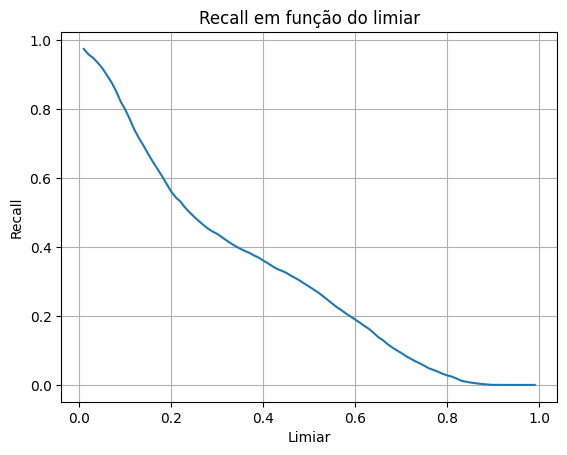

In [ ]:
import matplotlib.pyplot as plt

plt.plot(df_metrics["limiar"], df_metrics["recall"])
plt.xlabel("Limiar")
plt.ylabel("Recall")
plt.title("Recall em função do limiar")
plt.grid()
plt.show()


In [ ]:
import numpy as np

def melhor_limiar_por_recall(y_true, y_scores, recall_minimo):
    thresholds = np.linspace(0.001, 0.5, 200)

    melhor = None
    for thr in thresholds:
        preds = (y_scores >= thr).astype(int)
        rec = recall_score(y_true, preds)
        if rec >= recall_minimo:
            melhor = thr
    return melhor

limiar_escolhido = melhor_limiar_por_recall(y_test, y_scores, recall_minimo=0.95)
limiar_escolhido


np.float64(0.028582914572864323)

In [ ]:
limiar = 0.028582914572864323

y_pred_final = (y_scores >= limiar).astype(int)

In [ ]:
print("Recall:", recall_score(y_test, y_pred_final))
print("Precisão:", precision_score(y_test, y_pred_final))
print("Acurácia:", accuracy_score(y_test, y_pred_final))
print("F1:", f1_score(y_test, y_pred_final))

Recall: 0.9510225124591855
Precisão: 0.1795645543333658
Acurácia: 0.6730513502454992
F1: 0.30209072547628146
